# S&P 500 Equity+Options: Backtest and Signal Evaluation

**Chapter 16 - Strategy Simulation**

This notebook translates validation predictions into weekly, long-only equity
portfolios and evaluates the equal-weight top-$K$ baseline. Option-derived
features are predictive inputs only; the strategy trades equities.

**Learning objectives**

- verify decision-at-close and next-open execution with a random-signal smoke test;
- sweep equal-weight top-5, top-10, and top-20 portfolios for the primary label;
- rank only prediction sets with comparable validation-date coverage;
- interpret bootstrap and selection-adjusted uncertainty without opening the holdout.

Sections 1-2 register only missing primary-label baselines. Section 3 is
read-only and evaluates all five labels already present in the registry.

**Book Reference:** Chapter 16, Sections 16.4–16.8

**Prerequisites:** completed validation predictions from Chapters 11-15 and
the case-study protocol in `config/setup.yaml`.

In [1]:
"""Ch16 backtest and signal evaluation for S&P 500 equity and option features."""

import time
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import build_backtest_spec, serializable_backtest_spec
from case_studies.utils.backtest_runner import (
    normalize_prediction_columns,
    run_backtest,
    run_plumbing_test,
)
from case_studies.utils.notebook_render import selection_adjusted_leader_table
from case_studies.utils.registry import (
    backtest_dir,
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_entry_schemes_for,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
LABEL = ""
SPLIT = "validation"
TOP_K = 0  # 0 = use smallest top_k from setup.yaml backtest.sweep.top_k_grid
MAX_SYMBOLS = 0
FORCE_REBACKTEST = False  # Set True to re-backtest even if a complete backtest_hash exists
TOP_N_PREDICTIONS = None
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Setup & Plumbing Test

The protocol forms signals at Friday's close and submits orders for the next
available open, normally Monday. This event ordering prevents Friday-close
features from receiving a same-bar fill. A seeded random-signal run is a
plumbing smoke test: it can detect gross engine bias, but it cannot prove that
every research choice is unbiased.

### What is asked for, and what it resolves to

The parameters above are the request; the values the backtest runs on are resolved here and
carry different names. Keeping them apart means a run can print both, and a resolved value can
never quietly overwrite the request that produced it. Precedence is the same throughout: an
injected parameter wins, otherwise the case study's own declaration.

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
TOP_N = (
    TOP_N_PREDICTIONS
    if TOP_N_PREDICTIONS is not None
    else get_top_n_predictions(CASE_STUDY_ID, "signal")
)
BACKTEST_LABEL = LABEL or bt_config.primary_label

print(f"""Protocol term sheet
  Case study:    {CASE_STUDY_ID}
  Label:         {BACKTEST_LABEL}
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence}
  Commission:    {bt_config.commission_bps:.1f} bps
  Slippage:      {bt_config.slippage_bps:.1f} bps
  Total cost:    {bt_config.commission_bps + bt_config.slippage_bps:.1f} bps/leg
  Long/short:    {bt_config.long_short}
""")

Protocol term sheet
  Case study:    sp500_equity_option_analytics
  Label:         fwd_ret_5d
  Calendar:      NYSE
  Cadence:       weekly_friday_close
  Commission:    3.9 bps
  Slippage:      2.6 bps
  Total cost:    6.5 bps/leg
  Long/short:    False



In [5]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID, BACKTEST_LABEL, split="validation", max_symbols=MAX_SYMBOLS
)
n_assets = prices["symbol"].n_unique()
if TOP_K:
    PLUMBING_TOP_K = TOP_K
else:
    _feasible_top_k = get_top_k_values_for(CASE_STUDY_ID, BACKTEST_LABEL, n_assets)
    if not _feasible_top_k:
        raise ValueError(
            f"top_k_grid for {BACKTEST_LABEL!r} in {CASE_STUDY_ID} has no value < "
            f"n_assets={n_assets}; declare a feasible k in setup.yaml"
        )
    PLUMBING_TOP_K = _feasible_top_k[0]
print(
    f"Price support: {len(prices):,} rows across {n_assets} historical symbols; "
    f"plumbing-test top-K={PLUMBING_TOP_K}"
)

Price support: 250,916 rows across 554 historical symbols; plumbing-test top-K=5


In [6]:
strategy_spec = build_backtest_spec(
    CASE_STUDY_ID,
    bt_config,
    prices=prices,
    prediction_hash="plumbing_test",
    initial_cash=bt_config.initial_cash,
    chapter="ch16",
    signal={
        "method": "score_weighted_top_k",
        "top_k": PLUMBING_TOP_K,
        "long_short": bt_config.long_short,
    },
)

try:
    random_sharpe = run_plumbing_test(
        CASE_STUDY_ID,
        prices,
        strategy_spec,
        top_k=PLUMBING_TOP_K,
        seed=SEED,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )

    status = "PASS" if abs(random_sharpe) < 1.5 else "FAIL"
    print(f"Random signal Sharpe: {random_sharpe:.3f}  [{status}]")

    if abs(random_sharpe) >= 1.5:
        print("WARNING: random signal produces non-trivial Sharpe; inspect the pipeline")
except ValueError as e:
    if "zero variance" in str(e).lower():
        print(f"Plumbing test skipped: {e} (too few assets for meaningful test)")
        random_sharpe = 0.0
    else:
        raise

Random signal Sharpe: 0.797  [PASS]


## 2. Parametric Sweep

Sweep all primary-label prediction and concentration combinations through the
same `run_backtest()` function used for a single strategy. The sweep stores
every non-degenerate prediction result; the analysis below applies the stricter
maximum-coverage eligibility rule before ranking candidates.

The top-$K$ grid isolates concentration while holding sizing constant at equal
weight. Weekly top-5, top-10, and top-20 portfolios reveal whether a ranking
signal holds as the selected tail broadens.

In [7]:
pred_index = load_prediction_index(
    CASE_STUDY_ID,
    label=BACKTEST_LABEL,
    split=SPLIT,
)

if pred_index.is_empty():
    msg = f"No predictions found for {CASE_STUDY_ID}/{BACKTEST_LABEL}/{SPLIT}"
    raise RuntimeError(msg)

if TOP_N > 0:
    pred_index = pred_index.head(TOP_N)

n_predictions = len(pred_index)
print(f"Predictions to sweep: {n_predictions}")
ic_min, ic_max = pred_index["ic_mean"].min(), pred_index["ic_mean"].max()
if ic_min is not None:
    print(f"  Fold-aggregate IC range: {ic_min:.4f} to {ic_max:.4f}")
else:
    print("  IC range: not yet computed")

Predictions to sweep: 330
  Fold-aggregate IC range: -0.0168 to 0.0156


In [8]:
entry_schemes = get_entry_schemes_for(
    CASE_STUDY_ID, BACKTEST_LABEL, n_assets, long_short=bt_config.long_short
)
n_schemes = len(entry_schemes)

print(f"\nEntry schemes ({n_schemes}):")
for es in entry_schemes:
    print(f"  {es['name']}: {es['method']} (top_k={es.get('top_k', '-')})")

total_backtests = n_predictions * n_schemes
print(
    f"\nTotal grid: {n_predictions} predictions × {n_schemes} schemes = {total_backtests} backtests"
)


Entry schemes (3):
  ew_top5: equal_weight_top_k (top_k=5)
  ew_top10: equal_weight_top_k (top_k=10)
  ew_top20: equal_weight_top_k (top_k=20)

Total grid: 330 predictions × 3 schemes = 990 backtests


For each prediction set, content-addressed hashes identify concentration
variants already present in the registry. Only missing specifications need
execution.

In [9]:
def _artifact_matches_prediction_window(backtest_hash, predictions):
    artifact = backtest_dir(CASE_STUDY_ID, backtest_hash) / "daily_returns.parquet"
    if not artifact.exists():
        return False
    expected = predictions.select(pl.col("timestamp").cast(pl.Date).unique().sort())
    observed = pl.read_parquet(artifact).select(pl.col("timestamp").cast(pl.Date).unique().sort())
    return observed.equals(expected)


def _pending_specs(pred_row, predictions):
    pending = []
    n_existing = 0
    pred_hash = pred_row["prediction_hash"]
    for scheme in entry_schemes:
        signal = {
            "method": scheme["method"],
            "top_k": scheme.get("top_k", 20),
            "long_short": bt_config.long_short,
        }
        signal.update({k: v for k, v in scheme.items() if k not in ("name", "method")})
        spec = build_backtest_spec(
            CASE_STUDY_ID,
            bt_config,
            prices=prices,
            prediction_hash=pred_hash,
            initial_cash=bt_config.initial_cash,
            chapter="ch16",
            signal=signal,
        )
        backtest_hash = backtest_hash_from_parts(pred_hash, serializable_backtest_spec(spec))
        artifact_is_current = _artifact_matches_prediction_window(backtest_hash, predictions)
        if backtest_hash in existing_hashes and artifact_is_current:
            n_existing += 1
            continue
        pending.append((scheme, spec, backtest_hash in existing_hashes))
    return pending, n_existing

A single execution helper keeps the sweep cell focused on orchestration. It
returns the content hash on success and an error message on failure.

In [10]:
def _execute_one(pred_hash, spec, predictions, force_rebacktest):
    try:
        result = run_backtest(
            CASE_STUDY_ID,
            pred_hash,
            spec,
            prices=prices,
            predictions=predictions,
            label=BACKTEST_LABEL,
            register=True,
            force_rebacktest=FORCE_REBACKTEST or force_rebacktest,
            initial_cash=bt_config.initial_cash,
            calendar=bt_config.calendar,
        )
    except Exception as exc:
        return None, str(exc)
    return result.backtest_hash, None

Progress counts include cached and newly executed combinations. A complete
registry therefore finishes quickly without reading every prediction parquet.

In [11]:
t0 = time.time()
completed = failed = skipped = 0
existing_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="signal")
print(f"Existing equal-weight baseline hashes in registry: {len(existing_hashes):,}")

for pred_row in pred_index.iter_rows(named=True):
    pred_hash = pred_row["prediction_hash"]
    predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, pred_hash))
    pending_schemes, n_existing = _pending_specs(pred_row, predictions)
    skipped += n_existing
    if not pending_schemes:
        continue

    for scheme, spec, force_rebacktest in pending_schemes:
        backtest_hash, error = _execute_one(pred_hash, spec, predictions, force_rebacktest)
        if error:
            failed += 1
            print(f"  FAILED {pred_row['source']} / {scheme['name']}: {error}")
        else:
            completed += 1
            existing_hashes.add(backtest_hash)

        processed = completed + failed + skipped
        if processed % 20 == 0 or processed == total_backtests:
            elapsed = time.time() - t0
            rate = processed / elapsed if elapsed > 0 else 0
            print(f"  [{processed}/{total_backtests}] {rate:.1f} bt/s | failed: {failed}")

elapsed = time.time() - t0
print(
    f"\nSweep complete: {completed} run in {elapsed:.0f}s "
    f"({failed} failed, {skipped} already complete)"
)

Existing equal-weight baseline hashes in registry: 0


  [20/990] 1.0 bt/s | failed: 0


  [40/990] 1.0 bt/s | failed: 0


  [60/990] 1.0 bt/s | failed: 0


  [80/990] 1.0 bt/s | failed: 0


...

  [920/990] 0.9 bt/s | failed: 0


  [940/990] 0.9 bt/s | failed: 0


  [960/990] 0.9 bt/s | failed: 0


  [980/990] 0.9 bt/s | failed: 0


  [990/990] 0.9 bt/s | failed: 0

Sweep complete: 990 run in 1122s (0 failed, 0 already complete)


## 3. Signal Evaluation

This section is **read-only**. It evaluates the full registry across all five
labels, while the default sweep above covers only `fwd_ret_5d`. Eligibility
requires each prediction set to match the maximum validation-date coverage
within its family and label. This prevents a checkpoint scored on fewer dates
from winning on a different evaluation sample.

Every rank, interval and selection-adjustment statistic in this notebook is
computed on validation data, and the holdout stays available for one
evaluation after the strategy is fixed.

In [12]:
explorer = BacktestExplorer(CASE_STUDY_ID)
print(repr(explorer))

BacktestExplorer('sp500_equity_option_analytics', 990 runs: signal=990)


### Eligible Leaders

Requiring maximum decision-date coverage within each family and label removes
partial prediction histories before ranking. The output below reports the
cross-label PCA leader on `fwd_ret_10d`, while the default primary label
advances a different, label-specific set of model configurations.

In [13]:
all_baselines = explorer.best(stage="signal", top_n=9999)
search_context = explorer.search_context(stage="signal")
top = all_baselines.head(10)

top_k = [
    explorer.inspect(backtest_hash).spec["strategy"]["signal"]["top_k"]
    for backtest_hash in top["backtest_hash"]
]
top = top.with_columns(pl.Series("top_k", top_k, dtype=pl.Int64))

leader_predictions = normalize_prediction_columns(
    read_predictions(CASE_STUDY_ID, top["prediction_hash"][0])
)
print(
    f"Eligible baselines: {search_context['total']:,}; "
    f"median Sharpe: {search_context['median_sharpe']:.3f}; "
    f"positive: {search_context['pct_positive']:.1f}%"
)
print(
    f"Leader coverage: {leader_predictions['symbol'].n_unique()} symbols across "
    f"{leader_predictions['timestamp'].n_unique()} validation dates"
)

top.select(
    "source",
    "label",
    "top_k",
    pl.col("sharpe").round(3),
    pl.col("ic_mean_daily").round(4).alias("daily_ic"),
    pl.col("cagr").round(3),
    pl.col("max_drawdown").round(3),
)

Eligible baselines: 990; median Sharpe: 0.419; positive: 94.3%
Leader coverage: 287 symbols across 497 validation dates


source,label,top_k,sharpe,daily_ic,cagr,max_drawdown
str,str,i64,f64,f64,f64,f64
"""deep_learning/lstm_h64""","""fwd_ret_5d""",5,0.996,0.0045,0.403,-0.435
"""latent_factors/sae""","""fwd_ret_5d""",5,0.939,0.0063,0.27,-0.353
"""latent_factors/ipca""","""fwd_ret_5d""",10,0.918,0.0017,0.271,-0.359
"""latent_factors/ipca""","""fwd_ret_5d""",10,0.918,0.0017,0.271,-0.359
"""latent_factors/ipca""","""fwd_ret_5d""",5,0.914,0.0017,0.266,-0.342
"""latent_factors/ipca""","""fwd_ret_5d""",5,0.914,0.0017,0.266,-0.342
"""tabular_dl/tabm_s""","""fwd_ret_5d""",10,0.896,-0.0015,0.384,-0.585
"""tabular_dl/tabm_s""","""fwd_ret_5d""",10,0.896,-0.0015,0.384,-0.585
"""deep_learning/lstm_h64""","""fwd_ret_5d""",5,0.885,0.0034,0.329,-0.406


Downstream selection is label-specific and admits one checkpoint per distinct model
configuration. The primary label carries its own lineage: whichever configuration leads the
ranking above on another label does not displace it, because a strategy is built against one
target rather than against the strongest number in the sweep.

In [14]:
primary_advancing = resolve_best_predictions(
    CASE_STUDY_ID,
    BACKTEST_LABEL,
    split=SPLIT,
    top_n=10,
    stage="signal",
)
primary_advancing.select(
    "family",
    "config_name",
    "checkpoint_value",
    pl.col("sharpe").round(3),
)

family,config_name,checkpoint_value,sharpe
str,str,i64,f64
"""deep_learning""","""lstm_h64""",60,0.996
"""latent_factors""","""sae""",10,0.939
"""latent_factors""","""ipca""",0,0.918
"""tabular_dl""","""tabm_s""",100,0.896
"""gbm""","""leaves_7_huber""",150,0.874
"""gbm""","""leaves_31_mae""",300,0.866
"""deep_learning""","""nlinear""",20,0.864
"""deep_learning""","""patchtst""",5,0.786
"""latent_factors""","""cae""",35,0.781


### Family Dispersion and IC Translation

Family medians occupy a narrow Sharpe band, but PCA creates a much higher
latent-factor maximum. Across all eligible baselines, daily-pooled IC has only
a moderate rank association with portfolio Sharpe. Concentration, turnover,
and return-path differences therefore remain material after model ranking
quality is known. The figure reports the current coefficient from the registry.

In [15]:
families = explorer.compare_families(stage="signal")
ic_sharpe_rho = all_baselines.select(
    pl.corr("ic_mean_daily", "sharpe", method="spearman").alias("rho")
).item()

family_plot = families.sort("sharpe_median")
y_pos = list(range(family_plot.height))
family_labels = [name.replace("_", " ").title() for name in family_plot["family"]]

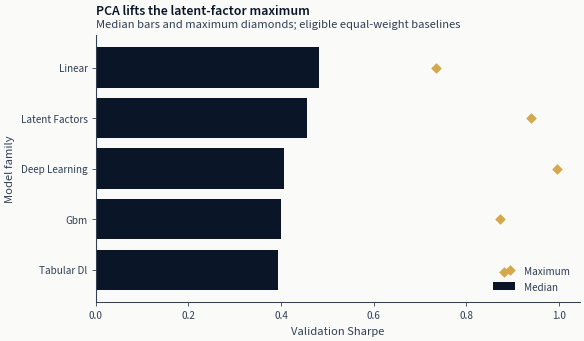

In [16]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
ax.barh(y_pos, family_plot["sharpe_median"], color=COLORS["blue"], label="Median")
ax.scatter(
    family_plot["sharpe_max"],
    y_pos,
    color=COLORS["amber"],
    marker="D",
    s=24,
    label="Maximum",
    zorder=3,
)
ax.set_yticks(y_pos, family_labels)
ax.set_xlabel("Validation Sharpe")
ax.set_ylabel("Model family")
zero_line(ax, axis="x")
ax.legend(frameon=False, loc="lower right")
add_message_title(
    ax,
    "PCA lifts the latent-factor maximum",
    "Median bars and maximum diamonds; eligible equal-weight baselines",
)
fig.show()

The same evaluation surface shows why prediction and portfolio diagnostics
cannot substitute for one another: similar IC values map to a wide Sharpe
range after tail selection and trading mechanics.

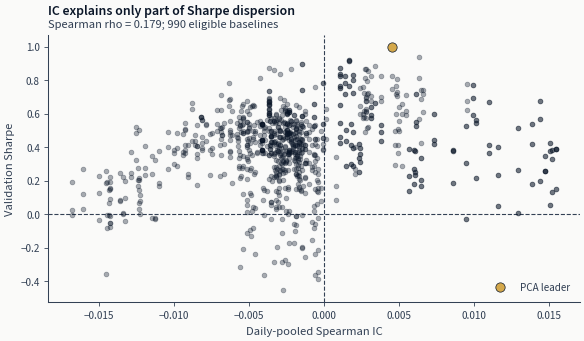

In [17]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
ax.scatter(
    all_baselines["ic_mean_daily"],
    all_baselines["sharpe"],
    color=COLORS["blue"],
    alpha=0.35,
    s=12,
)
ax.scatter(
    top["ic_mean_daily"][0],
    top["sharpe"][0],
    color=COLORS["amber"],
    edgecolor=COLORS["blue"],
    s=45,
    zorder=3,
    label="PCA leader",
)
zero_line(ax, axis="x")
zero_line(ax, axis="y")
ax.set_xlabel("Daily-pooled Spearman IC")
ax.set_ylabel("Validation Sharpe")
ax.legend(frameon=False, loc="lower right")
add_message_title(
    ax,
    "IC explains only part of Sharpe dispersion",
    f"Spearman rho = {ic_sharpe_rho:.3f}; {len(all_baselines):,} eligible baselines",
)
fig.show()

### Selection-Adjusted Uncertainty

A single-strategy bootstrap asks whether each return path clears zero. The
effective-rank deflated Sharpe ratio (DSR) additionally accounts for the
correlated variants tested within each family and label:

$$DSR = \Phi\left[\frac{(\hat{SR} - SR^*) \sqrt{T-1}}{\sqrt{1 - \hat{\gamma}_3 \hat{SR} + \frac{\hat{\gamma}_4 - 1}{4} \hat{SR}^2}}\right].$$

Read three columns together, because each answers a different question. The **block-bootstrap
Sharpe interval** asks whether one return path clears zero on its own. The **effective-rank
DSR** asks whether it still clears once the correlated variants tried within its own family
and label are counted, which is the number that accounts for the search. **PBO** asks how often
the in-sample leader underperforms out of sample; on two validation folds it has very low
resolution. These diagnostics support a validation candidate, not an
out-of-sample claim.

In [18]:
family_leaders = selection_adjusted_leader_table(CASE_STUDY_ID, stage="signal")
family_leaders.select(
    "family",
    "config_name",
    "label",
    pl.col("sharpe").round(3),
    pl.col("sharpe_ci95_lo").round(3).alias("ci_lo"),
    pl.col("sharpe_ci95_hi").round(3).alias("ci_hi"),
    pl.col("dsr_pvalue").round(4),
    "k_variants",
    "pbo",
)

family,config_name,label,sharpe,ci_lo,ci_hi,dsr_pvalue,k_variants,pbo
str,str,str,f64,f64,f64,f64,null,f64
"""deep_learning""","""lstm_h64""","""fwd_ret_5d""",0.996,-0.573,2.54,null,null,null
"""latent_factors""","""sae""","""fwd_ret_5d""",0.939,-0.266,2.315,null,null,null
"""tabular_dl""","""tabm_s""","""fwd_ret_5d""",0.896,-0.602,2.353,null,null,null
"""gbm""","""leaves_7_huber""","""fwd_ret_5d""",0.874,-0.366,2.229,null,null,null
"""linear""","""lasso_f0.85""","""fwd_ret_5d""",0.735,-0.893,2.293,null,null,null


The interval plot separates the favorable PCA result from the other family
leaders, whose uncertainty still includes zero.

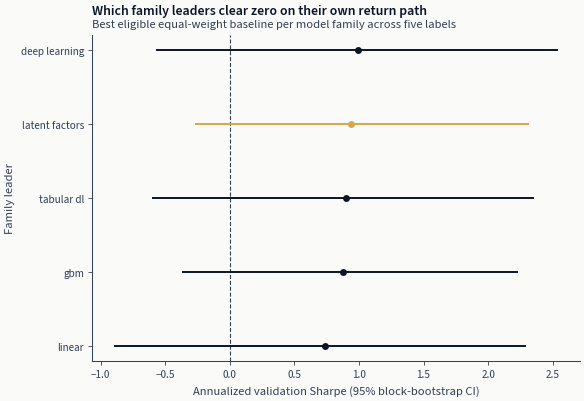

In [19]:
leader_plot = family_leaders.sort("sharpe")
leader_labels = [family.replace("_", " ") for family in leader_plot["family"]]

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)
for i, row in enumerate(leader_plot.iter_rows(named=True)):
    focal = row["family"] == "latent_factors"
    color = COLORS["amber"] if focal else COLORS["blue"]
    ax.errorbar(
        row["sharpe"],
        i,
        xerr=[
            [row["sharpe"] - row["sharpe_ci95_lo"]],
            [row["sharpe_ci95_hi"] - row["sharpe"]],
        ],
        fmt="o",
        color=color,
        capsize=3,
        markersize=5,
    )
ax.set_yticks(range(leader_plot.height), leader_labels)
ax.set_xlabel("Annualized validation Sharpe (95% block-bootstrap CI)")
ax.set_ylabel("Family leader")
zero_line(ax, axis="x")
add_message_title(
    ax,
    "Which family leaders clear zero on their own return path",
    "Best eligible equal-weight baseline per model family across five labels",
)
fig.show()

### Downstream Preview

Each row is the strongest registered variant at that pipeline layer for the same prediction
set. **That makes it a preview of what each layer can reach, not an attribution of the gain
to the layer**: every row has been selected, so a rise from one layer to the next mixes what
the layer contributes with what selecting over its variants contributes. A fixed
specification carried through every layer is what would separate the two, and it is not what
this table does.

In [20]:
stage_labels = {
    "signal": "equal-weight baseline",
    "allocation": "allocation",
    "cost_sensitivity": "cost sensitivity",
    "risk_overlay": "risk overlay",
}
best_pred = top["prediction_hash"][0]
progression = explorer.progression(best_pred)
progression.with_columns(
    pl.col("stage").replace_strict(stage_labels, default=pl.col("stage")).alias("pipeline_layer")
).select(
    "pipeline_layer",
    pl.col("sharpe").round(3),
    pl.col("cagr").round(3),
    pl.col("max_drawdown").round(3),
)

pipeline_layer,sharpe,cagr,max_drawdown
str,f64,f64,f64
"""equal-weight baseline""",0.996,0.403,-0.435


## Key Takeaways

1. **Coverage-aware ranking comes before comparison.** A prediction set measured on fewer
   validation dates than its rivals is not comparable to them, so partial histories are
   removed before any Sharpe is ranked rather than after.

2. **Selection is on validation backtest Sharpe, and it happens here.** IC ranked nothing
   upstream; every checkpoint of every model reached this notebook, and what advances is
   decided on money after costs rather than on rank correlation.

3. **A Sharpe that clears zero on its own has not yet cleared the search.** The
   effective-rank DSR is the column that counts the correlated variants tried within a family
   and label; two-fold PBO is reported beside it and is too coarse on this sample to support
   a stability claim either way.

4. **Each label keeps its own lineage.** The primary label's leader is chosen from the
   primary label's candidates, and a stronger number on another label does not displace it.
   Mixing them would select the label as well as the model, on the same validation data.

5. **IC and Sharpe are related and not interchangeable.** Portfolio construction reorders
   candidates that IC ranked one way, which is the entire reason selection waits until here.
   The measured coefficient is in the figure rather than frozen into this sentence.

6. **Everything here is validation data, on a current-constituent roster.** These are
   validation results on a universe that embeds survivorship bias, so they are research
   evidence rather than a prospective performance estimate.

**Next:** [`15_portfolio_management`](15_portfolio_management.ipynb) compares the declared
allocators within each label-specific lineage.